# Ejercicio #1 Sistema con IA Para clasificacion de reciclaje

Entrenar un modelo con las clases:
-cardboard
-glass
-metal
-paper
-plastic
-trash
Al final guardara el modelo y las clases para usarlo en Streamlit

Paso 1. Instalar dependencias

In [3]:
!pip install tensorflow numpy pillow matplotlib


In [4]:
!pip install kagglehub

In [5]:
from kagglehub import dataset_download

dataset_path = dataset_download("saumyamohandas/garbage-classification-image-dataset")

print("Ruta del dataset:", dataset_path)

Using Colab cache for faster access to the 'garbage-classification-image-dataset' dataset.
Ruta del dataset: /kaggle/input/garbage-classification-image-dataset


In [6]:
import os
for folder in os.listdir(dataset_path):
    print(folder)

dataset


In [7]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,

    image_size=(224,224),

    batch_size=32

)

class_names = train_ds.class_names

print(class_names)

Found 2972 files belonging to 1 classes.
['dataset']


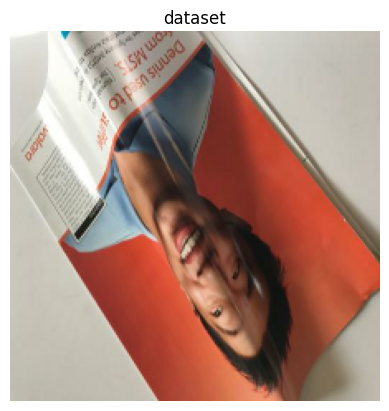

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    plt.imshow(images[0].numpy().astype("uint8"))

    plt.title(class_names[labels[0]])

    plt.axis("off")

Paso 2. Importar librerias

In [9]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

# Paso #3 Ajustar ruta del dataset

La carpeta del dataset debe verse asi:

garbage-classification/
cardboard/
glass/
metal/
paper/
plastic/
trash/

Paso 4. Cargar Imagenes

In [11]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

# Define DATA_DIR el path de kagglehub download

DATA_DIR = os.path.join(dataset_path, 'dataset')



train_data_path = os.path.join(DATA_DIR, 'Training')

val_data_path = os.path.join(DATA_DIR, 'Testing')

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_data_path,

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

)

val_ds = tf.keras.utils.image_dataset_from_directory(

    val_data_path,

    seed=SEED,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

)

class_names = train_ds.class_names

print("Clases detectadas:", class_names)

Found 2508 files belonging to 6 classes.
Found 464 files belonging to 6 classes.
Clases detectadas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


Paso 5. Ver algunas imagenes

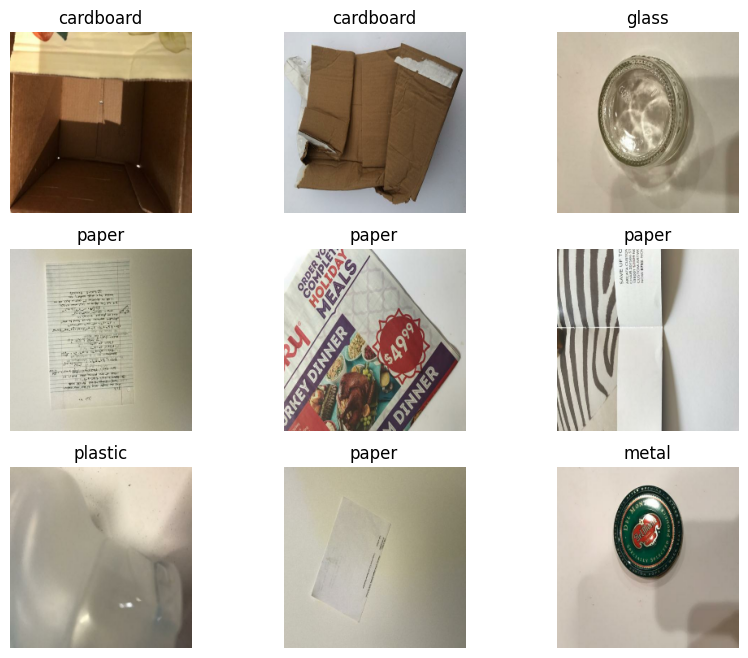

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

Paso 6. Preparar el dataset

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

val_ds = val_ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)).prefetch(AUTOTUNE)

Paso 7. Crear el modelo MobileNetV2

In [14]:
import tensorflow as tf

# Crear el modelo base MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# Congelar los pesos del modelo base
base_model.trainable = False

# Definir la entrada
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

# Pasar las imágenes por el modelo base
x = base_model(inputs, training=False)

# Capa de pooling global
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Capa de regularización
x = tf.keras.layers.Dropout(0.2)(x)

# Capa de salida
outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

# Crear el modelo final
model = tf.keras.Model(inputs, outputs)

# Compilar el modelo
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Mostrar el resumen del modelo
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##Paso 8. Repasar una vez EPOCH =1

In [15]:
# Número de épocas
EPOCHS = 10

# Callback para detener el entrenamiento si no mejora
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

# Entrenar el modelo
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5945 - loss: 1.0965 - val_accuracy: 0.7565 - val_loss: 0.7530
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8026 - loss: 0.5620 - val_accuracy: 0.7888 - val_loss: 0.6323
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.8313 - loss: 0.4736 - val_accuracy: 0.7953 - val_loss: 0.5826
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8608 - loss: 0.4107 - val_accuracy: 0.8060 - val_loss: 0.5377
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8824 - loss: 0.3567 - val_accuracy: 0.8211 - val_loss: 0.5395
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8927 - loss: 0.3250 - val_accuracy: 0.8297 - val_loss: 0.5236
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8975 - loss: 0.3026 - val_accuracy: 0.8276 - val_loss: 0.4864
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9107 - loss: 0.2771 - val_accuracy: 0.8319 - v

## Paso 9. Evaluar

In [16]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"Loss: {loss:.4f}")
print(f"Accuracy:{acc:.4f}")

Loss: 0.4627
Accuracy:0.8405


## Paso 10. Guardar el modelo

In [17]:
OUTPUT_DIR = Path("modelo_reciclaje_mobilenet")

OUTPUT_DIR.mkdir(exist_ok=True)

model.save(OUTPUT_DIR / "waste_mobilenet.h5")

#(HDF5- Hierarchical Data Format version 5)

model.save(OUTPUT_DIR / "waste_mobilenet.keras")

with open(OUTPUT_DIR / "class_names.json", "w", encoding="utf-8") as f:

    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.h5")

print("Modelo guardado en:", OUTPUT_DIR / "waste_mobilenet.keras")

print("Clases guardadas en:", OUTPUT_DIR / "class_names.json")

Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.h5
Modelo guardado en: modelo_reciclaje_mobilenet/waste_mobilenet.keras
Clases guardadas en: modelo_reciclaje_mobilenet/class_names.json


Predicciones:
Plástico: 78.31%
Basura: 18.54%
Cartón: 1.89%


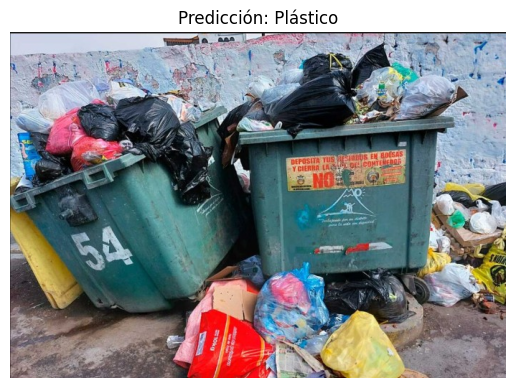

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

LABELS_ES = {
    "cardboard": "Cartón",
    "glass": "Vidrio",
    "metal": "Metal",
    "paper": "Papel",
    "plastic": "Plástico",
    "trash": "Basura",
}

def predict_image(img_path):
    if not os.path.exists(img_path):
        print(f"No existe la imagen: {img_path}")
        return None

    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    preds = model.predict(arr, verbose=0)[0]

    top3_idx = np.argsort(preds)[-3:][::-1]

    print("Predicciones:")
    for idx in top3_idx:
        raw = class_names[idx]
        print(f"{LABELS_ES.get(raw, raw)}: {preds[idx]*100:.2f}%")

    return class_names[np.argmax(preds)]

example_img_path = "basura.jpg"

pred = predict_image(example_img_path)

if pred is not None:
    plt.imshow(Image.open(example_img_path))
    plt.title(f"Predicción: {LABELS_ES.get(pred, pred)}")
    plt.axis("off")
    plt.show()

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
